In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid")

In [35]:
PROJECT_ROOT = Path("..").resolve()
file_path = PROJECT_ROOT / "data" / "augmented" / 'cbtbench_core_beliefs_augmented.jsonl'

df = pd.read_json(file_path, lines=True)

print(f"Total examples in dataset: {len(df)}")
display(df.head())

Total examples in dataset: 164


,text,core_beliefs,domain,persona,temperature,source_id,augment_idx
0,Been stuck on the same legacy codebase for nea...,"[I am powerless, weak, vulnerable, I am a vict...",career,software engineer,1.0,6,0
1,Has anyone ever been stuck with a client like ...,"[I am incompetent, I am powerless, weak, vulne...",health,freelancer,0.6,4678,0
2,My friend just bailed on our plans for tonight...,"[I am a victim, I am trapped, I am out of cont...",friendships,freelancer,0.6,4508,0
3,"I'm not sure what I'm looking for here, maybe ...","[I am helpless, I am undesirable, unwanted]",career,healthcare worker,0.6,4568,0
4,My girlfriend is packing a bag. She isn't shou...,"[I am incompetent, I am helpless, I am powerle...",relationships,manager,0.6,4684,0


In [36]:
counts = df.explode('core_beliefs')['core_beliefs'].value_counts()

for belief, count in counts.items():
    print(f'"{belief}": {count},')

"I am worthless, waste": 61,
"I am undesirable, unwanted": 53,
"I am unlovable": 49,
"I am helpless": 48,
"I am defective": 47,
"I am bound to be abandoned": 46,
"I am powerless, weak, vulnerable": 44,
"I am bound to be rejected": 43,
"I am trapped": 40,
"I am a victim": 37,
"I am a failure, loser": 32,
"I am bound to be alone": 31,
"I am out of control": 30,
"I am bad - dangerous, toxic, evil": 30,
"I am immoral": 30,
"I don’t deserve to live": 24,
"I am incompetent": 20,
"I am unattractive": 18,
"I am needy": 15,


In [37]:
# 1. Explode the lists into individual rows
exploded_beliefs = df.explode('core_beliefs')

# 2. Count the occurrences of each unique belief
belief_counts = exploded_beliefs['core_beliefs'].value_counts().reset_index()
belief_counts.columns = ['Core Belief', 'Example Count']

# 3. Calculate the percentage of total narratives that contain this belief
belief_counts['% of Total Narratives'] = (belief_counts['Example Count'] / len(df)) * 100

display(belief_counts)

,Core Belief,Example Count,% of Total Narratives
0,"I am worthless, waste",61,37.195122
1,"I am undesirable, unwanted",53,32.317073
2,I am unlovable,49,29.878049
3,I am helpless,48,29.268293
4,I am defective,47,28.658537
5,I am bound to be abandoned,46,28.048780
6,"I am powerless, weak, vulnerable",44,26.829268
7,I am bound to be rejected,43,26.219512
8,I am trapped,40,24.390244
9,I am a victim,37,22.560976


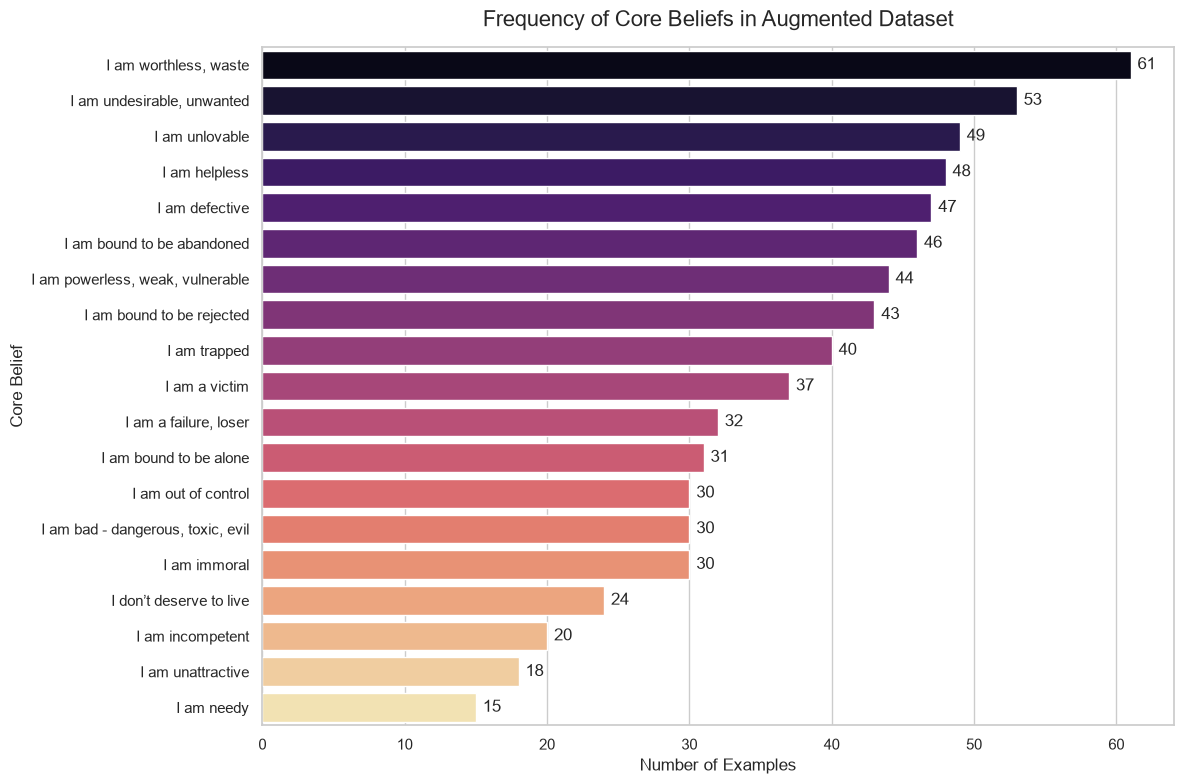

In [38]:
plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=belief_counts, 
    x='Example Count', 
    y='Core Belief', 
    palette='magma'
)

plt.title('Frequency of Core Beliefs in Augmented Dataset', fontsize=16, pad=15)
plt.xlabel('Number of Examples', fontsize=12)
plt.ylabel('Core Belief', fontsize=12)

# Add exact numbers to the end of each bar
for i in ax.containers:
    ax.bar_label(i, padding=5)

plt.tight_layout()
plt.show()

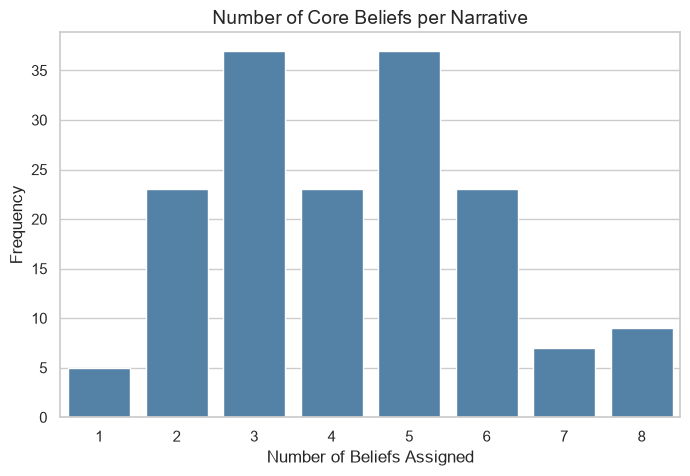

Average beliefs per narrative: 4.26
Max beliefs in a single narrative: 8


In [39]:
# Calculate how many beliefs are in each row
df['num_beliefs'] = df['core_beliefs'].apply(len)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='num_beliefs', color='steelblue')
plt.title('Number of Core Beliefs per Narrative', fontsize=14)
plt.xlabel('Number of Beliefs Assigned', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

print(f"Average beliefs per narrative: {df['num_beliefs'].mean():.2f}")
print(f"Max beliefs in a single narrative: {df['num_beliefs'].max()}")

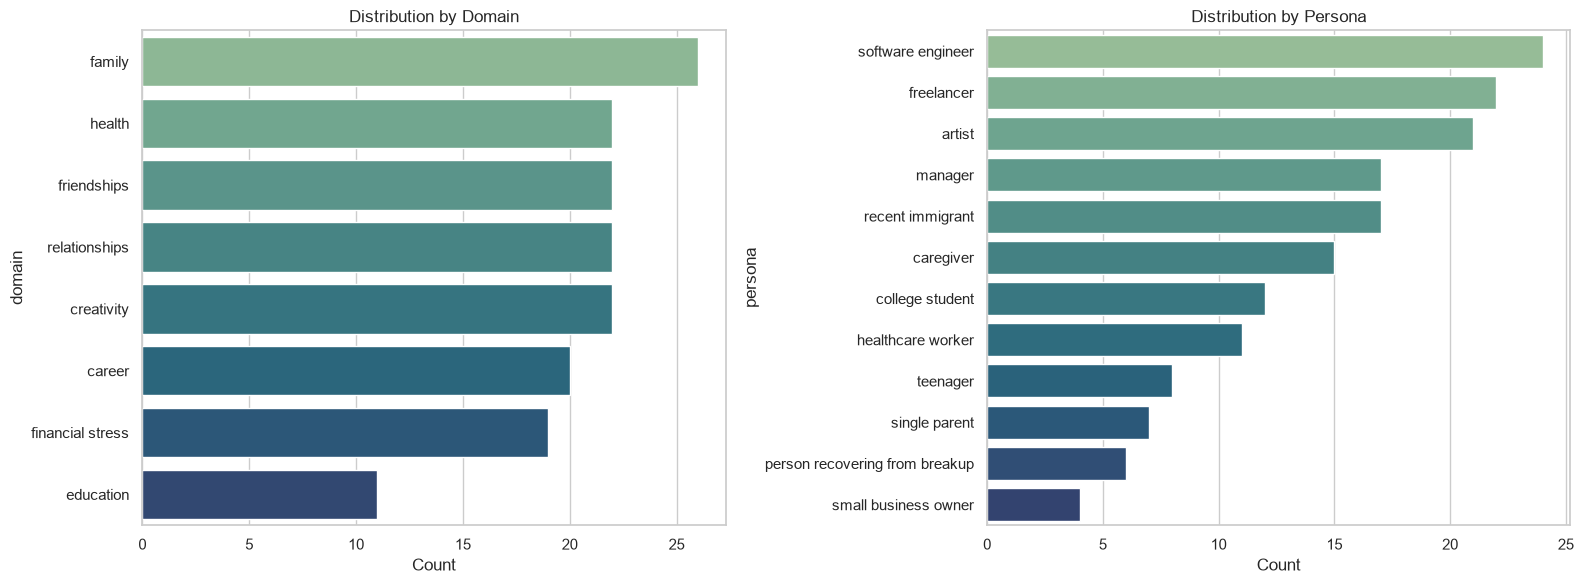

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Domain distribution
sns.countplot(data=df, y='domain', ax=axes[0], palette='crest', order=df['domain'].value_counts().index)
axes[0].set_title('Distribution by Domain')
axes[0].set_xlabel('Count')

# Persona distribution
sns.countplot(data=df, y='persona', ax=axes[1], palette='crest', order=df['persona'].value_counts().index)
axes[1].set_title('Distribution by Persona')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()